CoT experiment pipeline (graded on experiments).

Core hypothesis (Experiment 1):
    Chain-of-Thought prompting improves accuracy on multi-step REASONING tasks
    (GSM8K math) but gives little to no gain (or a small drop) on a shallow
    CLASSIFICATION task (SST-2 sentiment). The *contrast* is the result.

Depth (Experiment 2, optional):
    Self-consistency (sample k CoT paths, majority vote) further improves GSM8K.

DESIGN PRINCIPLE: change ONE variable at a time.
    - Exp 1: fix model + data, vary PROMPTING (direct / zero-shot CoT / few-shot CoT).
    - Exp 2: fix model + data + prompt (zero-shot CoT), vary k (# sampled paths).

WORKFLOW:
    1. Run with DEBUG=True on CPU (tiny model, 5 examples) until it runs end-to-end.
    2. Flip DEBUG=False, run on GPU.
    3. Analyze results.csv locally (no GPU) -> table + chart + write-up.

In [11]:
!pip install torch transformers datasets bitsandbytes accelerate matplotlib

In [12]:
import re, json, random, collections
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import csv, collections
import matplotlib.pyplot as plt

CONFIG

In [13]:
DEBUG = False   # True = CPU smoke test; False = real GPU run

if DEBUG:
    MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"   # tiny, runs on CPU
    N_PER_TASK = 5
    LOAD_4BIT = False
else:
    MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"     # the real model
    N_PER_TASK = 50            # sample size per task; 150-200 is plenty
    LOAD_4BIT = True

SEED = 0
random.seed(SEED)
RUN_SELF_CONSISTENCY = True   # True for Experiment 2 (needs more GPU time)
SC_K = 5                       # number of sampled paths for self-consistency

LOAD MODEL

In [14]:
def load_model():
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    kwargs = {"torch_dtype": torch.float16} if not DEBUG else {}
    if LOAD_4BIT:
        from transformers import BitsAndBytesConfig
        kwargs = {"quantization_config": BitsAndBytesConfig(load_in_4bit=True),
                  "device_map": "auto"}
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **kwargs)
    if not LOAD_4BIT:
        model = model.to("cuda" if torch.cuda.is_available() else "cpu")
    print(torch.cuda.is_available(), torch.cuda.get_device_name(0))
    return tok, model

def generate(tok, model, user_msg, sample=False, max_new=256):
    msgs = [{"role": "user", "content": user_msg}]
    prompt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    ids = tok(prompt, return_tensors="pt").to(model.device)
    gen = dict(max_new_tokens=max_new, pad_token_id=tok.eos_token_id)
    if sample:
        gen.update(do_sample=True, temperature=0.7, top_p=0.95)
    else:
        gen.update(do_sample=False)
    out = model.generate(**ids, **gen)
    return tok.decode(out[0][ids.input_ids.shape[1]:], skip_special_tokens=True)

DATA

In [15]:
def load_tasks():
    gsm = load_dataset("openai/gsm8k", "main", split="test").shuffle(seed=SEED).select(range(N_PER_TASK))
    sst = load_dataset("nyu-mll/glue", "sst2", split="validation").shuffle(seed=SEED).select(range(N_PER_TASK))
    gsm_items = [{"q": r["question"], "gold": extract_gold_gsm(r["answer"])} for r in gsm]
    sst_items = [{"q": r["sentence"], "gold": "positive" if r["label"] == 1 else "negative"} for r in sst]
    return {"gsm8k": gsm_items, "sst2": sst_items}

def extract_gold_gsm(ans):          # ground truth format ends with "#### 42"
    return ans.split("####")[-1].strip().replace(",", "")

PROMPTS

In [16]:
# Three parallel conditions per task. Keep them minimal so the ONLY
# difference across conditions is the reasoning instruction.
GSM_FEWSHOT = (
    "Q: Natalia sold 48 clips in April and half as many in May. How many total?\n"
    "A: Let's think step by step. May = 48/2 = 24. Total = 48 + 24 = 72. The answer is 72.\n\n"
    "Q: A robe takes 2 bolts of blue fiber and half that much white fiber. How many bolts in total?\n"
    "A: Let's think step by step. White = 2/2 = 1. Total = 2 + 1 = 3. The answer is 3.\n\n"
    "Q: Weng earns $12 an hour babysitting. Yesterday she babysat for 50 minutes. How much did she earn?\n"
    "A: Let's think step by step. Per minute = 12/60 = 0.2. Earned = 0.2 * 50 = 10. The answer is 10.\n\n"
)
SST_FEWSHOT = (
    "Review: 'a dull, lifeless bore'\n"
    "A: Let's think step by step. The words are negative. The answer is negative.\n\n"
    "Review: 'a warm, funny, and deeply moving triumph'\n"
    "A: Let's think step by step. The words are positive. The answer is positive.\n\n"
)

def build_prompt(task, q, condition):
    if task == "gsm8k":
        base = f"Q: {q}\nA:"
        if condition == "direct":
            return base + " Give only the final numeric answer as 'The answer is <n>.'"
        if condition == "zeroshot_cot":
            return base + " Let's think step by step. End with 'The answer is <n>.'"
        if condition == "fewshot_cot":
            return GSM_FEWSHOT + base + " Let's think step by step. End with 'The answer is <n>.'"
    else:  # sst2
        base = f"Review: '{q}'\nSentiment (positive or negative):"
        if condition == "direct":
            return base + " Answer with one word."
        if condition == "zeroshot_cot":
            return base + " Let's think step by step, then end with 'The answer is <positive/negative>.'"
        if condition == "fewshot_cot":
            return SST_FEWSHOT + base + " Let's think step by step, then end with 'The answer is <positive/negative>.'"

EXTRACTION

In [17]:
# The #1 source of fake results. Test this hard.
def _clean(text):
    # strip LaTeX/markdown wrappers that hide the final number
    text = text.replace("\\(", " ").replace("\\)", " ").replace("\\[", " ").replace("\\]", " ")
    text = text.replace("\\$", " ").replace("$", " ").replace("**", " ")
    text = re.sub(r"\\boxed\{([^}]*)\}", r" \1 ", text)   # \boxed{800} -> 800
    text = text.replace("\\", " ")
    return text

def extract_pred(task, text):
    text = _clean(text)
    if task == "gsm8k":
        # 1) explicit conclusion cues; take the LAST match
        cues = re.findall(
            r"(?:answer is|answer:|answer\s*=|final answer[^0-9\-]*|=)\s*(-?[\d,]+(?:\.\d+)?)",
            text, re.I)
        if cues:
            return cues[-1].replace(",", "").rstrip(".")
        # 2) fallback: last number on the LAST non-empty line only
        for line in reversed([l for l in text.strip().splitlines() if l.strip()]):
            nums = re.findall(r"-?[\d,]+(?:\.\d+)?", line)
            if nums:
                return nums[-1].replace(",", "").rstrip(".")
        return None
    else:  # sst2
        cues = re.findall(r"answer is\s*(positive|negative)", text, re.I)
        if cues:
            return cues[-1].lower()
        hits = re.findall(r"(positive|negative)", text, re.I)   # last mention = conclusion
        return hits[-1].lower() if hits else None

def correct(task, pred, gold):
    if pred is None: return False
    if task == "gsm8k":
        try: return abs(float(pred) - float(gold)) < 1e-4
        except ValueError: return False
    return pred == gold


RUN

In [18]:
def run():
    tok, model = load_model()
    tasks = load_tasks()
    conditions = ["direct", "zeroshot_cot", "fewshot_cot"]
    rows = []
    for task, items in tasks.items():
        for cond in conditions:
            n_ok = 0
            for it in items:
                out = generate(tok, model, build_prompt(task, it["q"], cond),
                               max_new=(512 if "cot" in cond else 64))
                pred = extract_pred(task, out)
                ok = correct(task, pred, it["gold"])
                n_ok += ok
                rows.append({"task": task, "condition": cond, "pred": pred,
                             "gold": it["gold"], "correct": ok, "raw": out[-800:]})
            acc = n_ok / len(items)
            print(f"{task:6s} | {cond:13s} | acc = {acc:.3f}  ({n_ok}/{len(items)})")

    if RUN_SELF_CONSISTENCY:
        print("\n--- Experiment 2: self-consistency on GSM8K ---")
        n_ok = 0
        for it in tasks["gsm8k"]:
            votes = []
            for _ in range(SC_K):
                out = generate(tok, model,
                               build_prompt("gsm8k", it["q"], "zeroshot_cot"), sample=True)
                p = extract_pred("gsm8k", out)
                if p is not None: votes.append(p)
            pred = collections.Counter(votes).most_common(1)[0][0] if votes else None
            n_ok += correct("gsm8k", pred, it["gold"])
        print(f"gsm8k  | self-consistency(k={SC_K}) | acc = {n_ok/len(tasks['gsm8k']):.3f}")

    with open("results.csv", "w") as f:
        import csv
        w = csv.DictWriter(f, fieldnames=rows[0].keys()); w.writeheader(); w.writerows(rows)
    print("\nSaved per-example results to results.csv")

if __name__ == "__main__":
    run()


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

True Tesla T4
gsm8k  | direct        | acc = 0.160  (8/50)
gsm8k  | zeroshot_cot  | acc = 0.920  (46/50)
gsm8k  | fewshot_cot   | acc = 0.860  (43/50)
sst2   | direct        | acc = 0.940  (47/50)
sst2   | zeroshot_cot  | acc = 0.920  (46/50)
sst2   | fewshot_cot   | acc = 0.940  (47/50)

--- Experiment 2: self-consistency on GSM8K ---
gsm8k  | self-consistency(k=5) | acc = 0.680

Saved per-example results to results.csv


PLOT


condition           GSM8K    SST-2
----------------------------------------
Direct              0.160    0.940
Zero-shot CoT       0.920    0.920
Few-shot CoT        0.860    0.940
Self-consistency    0.680        -


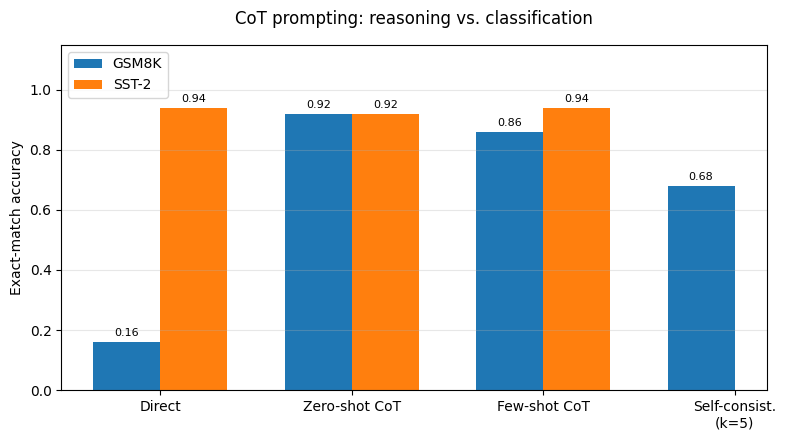

Saved -> accuracy_chart.png


In [20]:
RESULTS = "results.csv"
SC_ACC  = 0.680   # Replaced with self-consistency accuracy, otherwise None to omit

COND_ORDER = ["direct", "zeroshot_cot", "fewshot_cot"]
COND_LABEL = {"direct": "Direct", "zeroshot_cot": "Zero-shot CoT", "fewshot_cot": "Few-shot CoT"}
TASK_ORDER = ["gsm8k", "sst2"]
TASK_LABEL = {"gsm8k": "GSM8K", "sst2": "SST-2"}

rows = list(csv.DictReader(open(RESULTS)))
n_ok, n_tot = collections.Counter(), collections.Counter()
for r in rows:
    k = (r["task"], r["condition"])
    n_tot[k] += 1
    n_ok[k]  += (str(r["correct"]).lower() == "true")

def acc(task, cond):
    k = (task, cond)
    return n_ok[k] / n_tot[k] if n_tot[k] else float("nan")

# 1) printed table
print(f"\n{'condition':16s} " + " ".join(f"{TASK_LABEL[t]:>8s}" for t in TASK_ORDER))
print("-" * 40)
for c in COND_ORDER:
    print(f"{COND_LABEL[c]:16s} " + " ".join(f"{acc(t,c):8.3f}" for t in TASK_ORDER))
if SC_ACC is not None:
    print(f"{'Self-consistency':16s} {SC_ACC:8.3f} {'-':>8s}")

# 2) grouped bar chart
gsm_labels = [COND_LABEL[c] for c in COND_ORDER]
gsm_vals   = [acc("gsm8k", c) for c in COND_ORDER]
sst_vals   = [acc("sst2",  c) for c in COND_ORDER]

# add self-consistency as a 4th GSM8K-only bar
if SC_ACC is not None:
    gsm_labels.append("Self-consist.\n(k=5)")
    gsm_vals.append(SC_ACC)
    sst_vals.append(float("nan"))   # no SST-2 bar for this condition

x = range(len(gsm_labels)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar([i - w/2 for i in x], gsm_vals, w, label="GSM8K")
ax.bar([i + w/2 for i in x], sst_vals, w, label="SST-2")
ax.set_xticks(list(x)); ax.set_xticklabels(gsm_labels)
ax.set_ylabel("Exact-match accuracy"); ax.set_ylim(0, 1.15)
ax.set_title("CoT prompting: reasoning vs. classification", pad=15)
ax.legend(); ax.grid(axis="y", alpha=0.3)
for i in x:
    if not (gsm_vals[i] != gsm_vals[i]):   # skip NaN
        ax.text(i - w/2, gsm_vals[i] + .02, f"{gsm_vals[i]:.2f}", ha="center", fontsize=8)
    if not (sst_vals[i] != sst_vals[i]):
        ax.text(i + w/2, sst_vals[i] + .02, f"{sst_vals[i]:.2f}", ha="center", fontsize=8)
fig.tight_layout()
fig.savefig("accuracy_chart.png", dpi=150)
plt.show()
print("Saved -> accuracy_chart.png")